# **SET UP**

In [3]:
pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.1 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.utils import resample
import category_encoders as ce
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
from sklearn.model_selection import cross_val_score, learning_curve
from sklearn.neighbors import KNeighborsRegressor

import joblib
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/loan-approval-classification-data


# **Load the Dataset and Explore**

In [ ]:
# Load the dataset
data = pd.read_csv('/kaggle/input/loan-approval-classification-data/loan_data.csv')

data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
#describe the dataset
print("Shape of the dataset:", data.shape)
print("\nDataset Information:")
print(data.info())
print("\nStatistical Summary:")
display(data.describe().T)

Shape of the dataset: (45000, 14)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [ ]:
# Check for missing and duplicated values
print(f'\nMissing values: {data.isna().sum().sum()}')
print(f'Duplicated values: {data.duplicated().sum()}')


Missing values: 0
Duplicated values: 0


In [ ]:
# Display the number of unique values in each column
print("\nUnique Values in Each Column:")
print(data.nunique())


Unique Values in Each Column:
person_age                           60
person_gender                         2
person_education                      5
person_income                     33989
person_emp_exp                       63
person_home_ownership                 4
loan_amnt                          4483
loan_intent                           6
loan_int_rate                      1302
loan_percent_income                  64
cb_person_cred_hist_length           29
credit_score                        340
previous_loan_defaults_on_file        2
loan_status                           2
dtype: int64


In [ ]:
# Separate numerical and categorical columns
numerical_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
non_numerical_columns = data.select_dtypes(include=['object']).columns.tolist()

# Display the lists of numerical and categorical columns
print("\nNumerical Columns:", numerical_columns)
print("Categorical Columns:", non_numerical_columns)


Numerical Columns: ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'loan_status']
Categorical Columns: ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']


In [ ]:
# Display unique values for each categorical column
for col in non_numerical_columns:
    print(f"\nColumn: {col}")
    print(f"Unique Values: {data[col].unique()}")


Column: person_gender
Unique Values: ['female' 'male']

Column: person_education
Unique Values: ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

Column: person_home_ownership
Unique Values: ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Column: loan_intent
Unique Values: ['PERSONAL' 'EDUCATION' 'MEDICAL' 'VENTURE' 'HOMEIMPROVEMENT'
 'DEBTCONSOLIDATION']

Column: previous_loan_defaults_on_file
Unique Values: ['No' 'Yes']


# **Data Exploration Analysis**

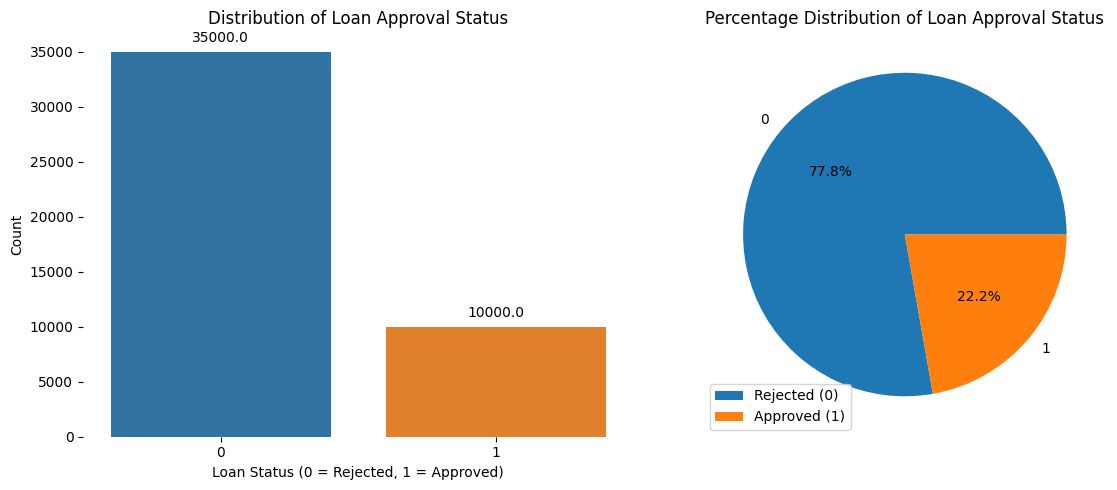

In [ ]:
# Create subplots for loan status visualization
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

# Count the occurrences of each loan status
loan_status_counts = data['loan_status'].value_counts()

# Bar plot for loan status distribution
sns.barplot(x=loan_status_counts.index, y=loan_status_counts, ax=axes[0], palette='tab10')
axes[0].set_title('Distribution of Loan Approval Status')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Loan Status (0 = Rejected, 1 = Approved)')

# Annotate bar plot with counts
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center',
                     xytext=(0, 10), textcoords='offset points')

sns.despine(left=True, bottom=True)

# Pie chart for percentage distribution of loan status
loan_status_percentage = loan_status_counts / loan_status_counts.sum() * 100
axes[1].pie(loan_status_percentage, labels=loan_status_percentage.index, autopct='%1.1f%%',
            colors=sns.color_palette('tab10'))
axes[1].set_title('Percentage Distribution of Loan Approval Status')
plt.legend(['Rejected (0)', 'Approved (1)'])

# Adjust layout and show plot
plt.tight_layout()
plt.show()

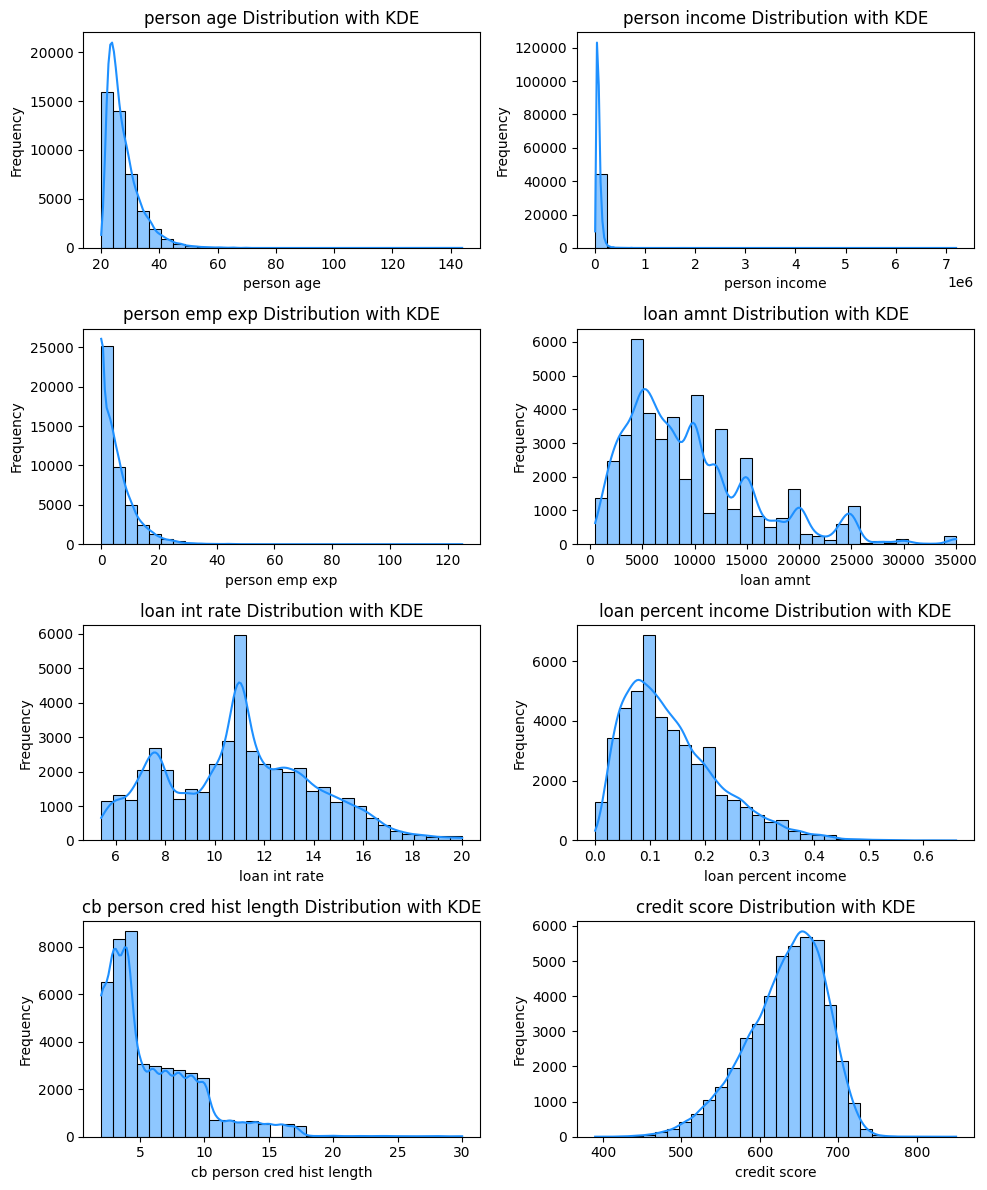

In [ ]:
# Function to perform univariate analysis for numeric columns
def univariate_analysis(data, columns):
    plt.figure(figsize=(10, 12))

    for i, column in enumerate(columns, 1):
        plt.subplot(4, 2, i)
        sns.histplot(data[column], kde=True, bins=30, color='dodgerblue')
        plt.title(f'{column.replace("_", " ")} Distribution with KDE')
        plt.xlabel(column.replace('_', ' '))
        plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

columns_to_analyze = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']

univariate_analysis(data, columns_to_analyze)

In [ ]:
def plot_categorical_distribution(column_name, data=data):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    sns.countplot(y=column_name, data=data, palette='muted')
    plt.title(f'Distribution of {column_name}')

    ax = plt.gca()
    for p in ax.patches:
        ax.annotate(f'{int(p.get_width())}', (p.get_width(), p.get_y() + p.get_height() / 2),
                    ha='center', va='center', xytext=(10, 0), textcoords='offset points')

    sns.despine(left=True, bottom=True)

    plt.subplot(1, 2, 2)
    data[column_name].value_counts().plot.pie(autopct='%1.1f%%', colors=sns.color_palette('muted'), startangle=90, explode=[0.05]*data[column_name].nunique())
    plt.title(f'Percentage Distribution of {column_name}')
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

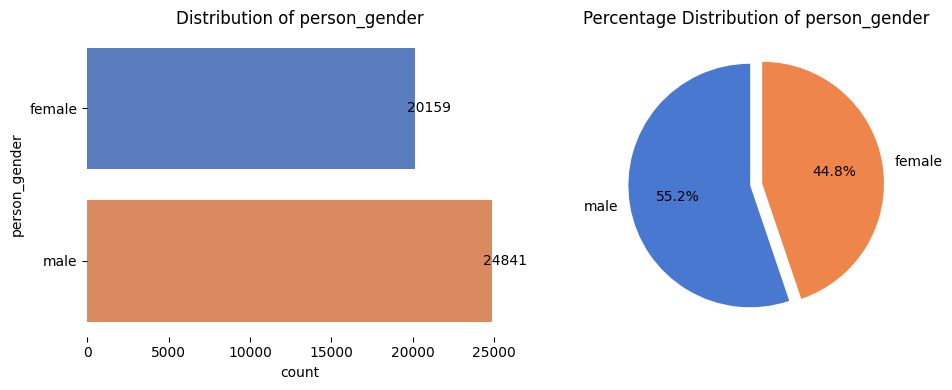

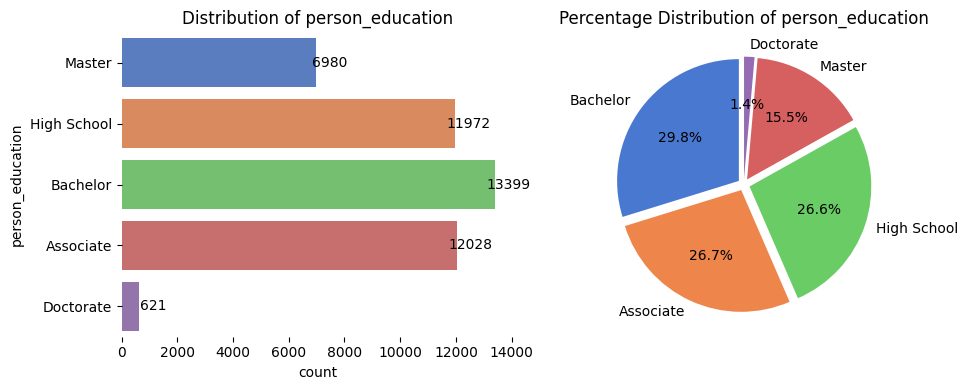

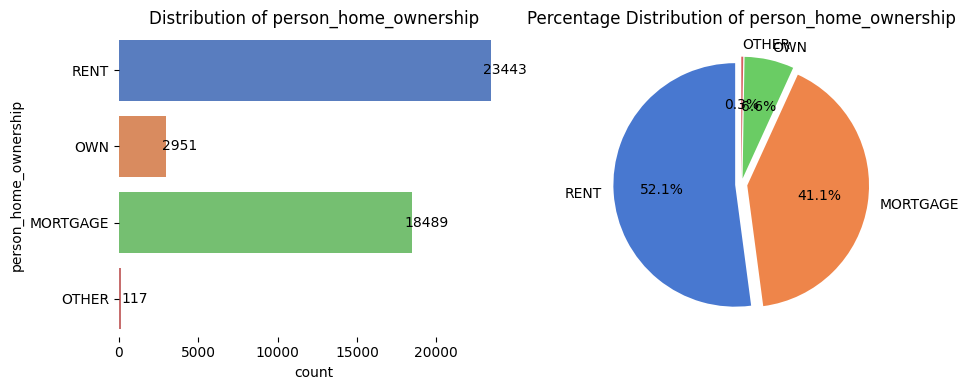

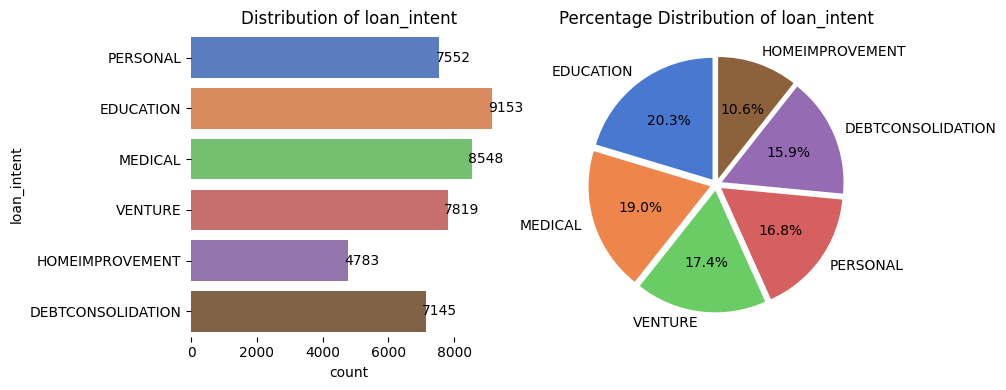

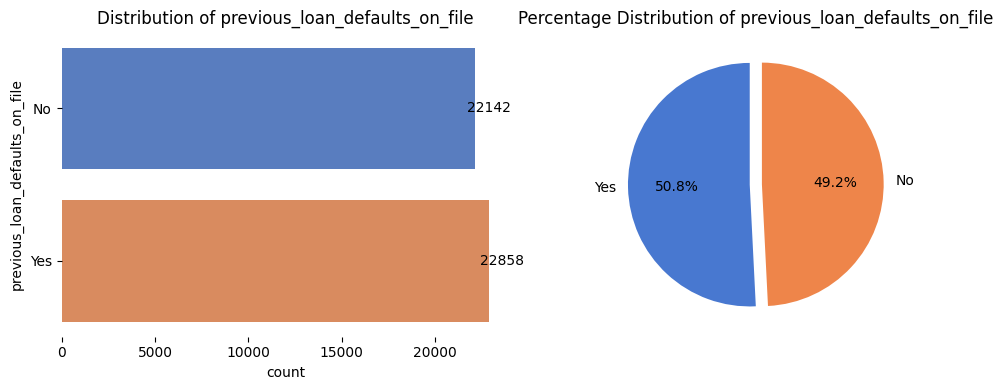

In [ ]:
plot_categorical_distribution('person_gender')
plot_categorical_distribution('person_education')
plot_categorical_distribution('person_home_ownership')
plot_categorical_distribution('loan_intent')
plot_categorical_distribution('previous_loan_defaults_on_file')

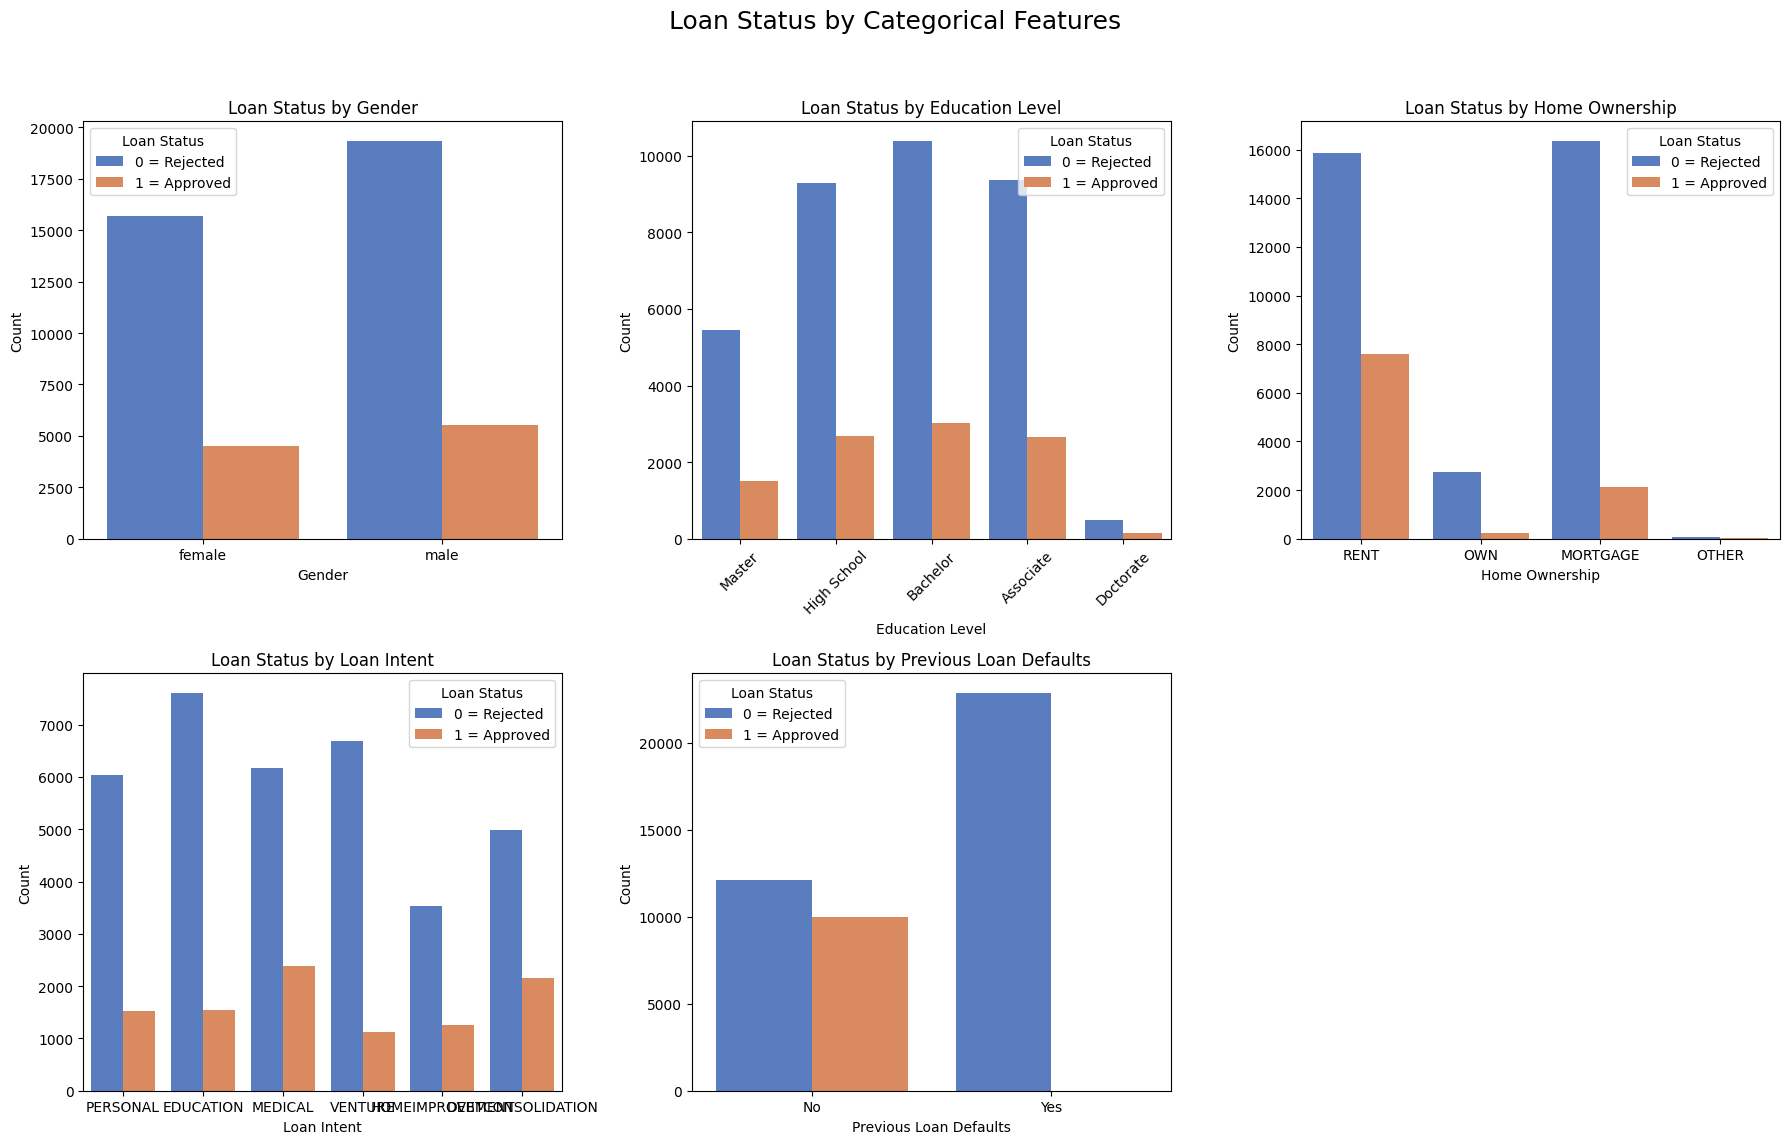

In [ ]:
# Create subplots for loan status by categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle("Loan Status by Categorical Features", fontsize=18)

# Visualization for person_gender vs loan_status
sns.countplot(data=data, x='person_gender', hue='loan_status', ax=axes[0, 0], palette='muted')
axes[0, 0].set_title("Loan Status by Gender")
axes[0, 0].set_xlabel("Gender")
axes[0, 0].set_ylabel("Count")
axes[0, 0].legend(title='Loan Status', labels=['0 = Rejected', '1 = Approved'])

# Visualization for person_education vs loan_status
sns.countplot(data=data, x='person_education', hue='loan_status', ax=axes[0, 1], palette='muted')
axes[0, 1].set_title("Loan Status by Education Level")
axes[0, 1].set_xlabel("Education Level")
axes[0, 1].set_ylabel("Count")
axes[0, 1].legend(title='Loan Status', labels=['0 = Rejected', '1 = Approved'])
axes[0, 1].tick_params(axis='x', rotation=45)

# Visualization for person_home_ownership vs loan_status
sns.countplot(data=data, x='person_home_ownership', hue='loan_status', ax=axes[0, 2], palette='muted')
axes[0, 2].set_title("Loan Status by Home Ownership")
axes[0, 2].set_xlabel("Home Ownership")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend(title='Loan Status', labels=['0 = Rejected', '1 = Approved'])

# Visualization for loan_intent vs loan_status
sns.countplot(data=data, x='loan_intent', hue='loan_status', ax=axes[1, 0], palette='muted')
axes[1, 0].set_title("Loan Status by Loan Intent")
axes[1, 0].set_xlabel("Loan Intent")
axes[1, 0].set_ylabel("Count")
axes[1, 0].legend(title='Loan Status', labels=['0 = Rejected', '1 = Approved'])

# Visualization for previous_loan_defaults_on_file vs loan_status
sns.countplot(data=data, x='previous_loan_defaults_on_file', hue='loan_status', ax=axes[1, 1], palette='muted')
axes[1, 1].set_title("Loan Status by Previous Loan Defaults")
axes[1, 1].set_xlabel("Previous Loan Defaults")
axes[1, 1].set_ylabel("Count")
axes[1, 1].legend(title='Loan Status', labels=['0 = Rejected', '1 = Approved'])

# Hide the last subplot (if not needed)
fig.delaxes(axes[1][2])

# Adjust layout and show plot
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

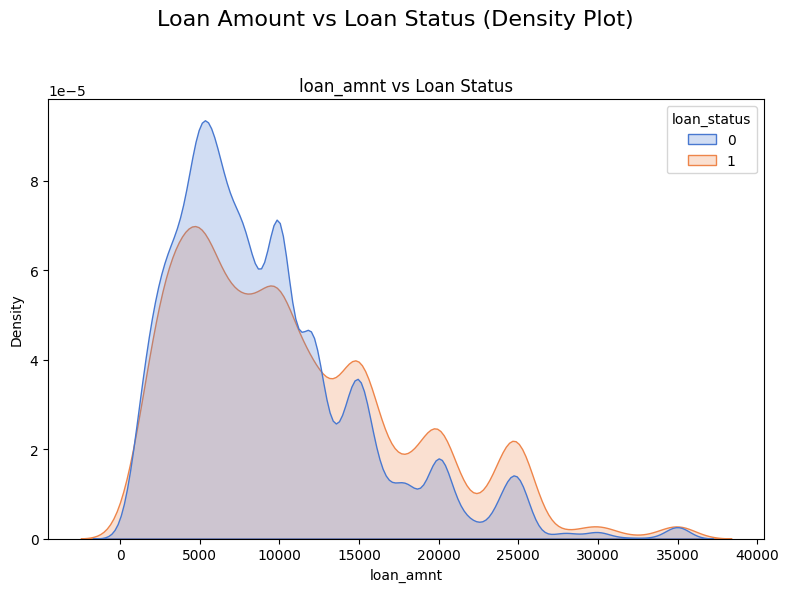

In [ ]:
# Create a single subplot
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Loan Amount vs Loan Status (Density Plot)', fontsize=16)

# Plot density for loan_amnt vs loan_status
sns.kdeplot(data=data, x='loan_amnt', hue='loan_status', ax=ax, fill=True, common_norm=False, palette='muted')
ax.set_title('loan_amnt vs Loan Status')
ax.set_xlabel('loan_amnt')
ax.set_ylabel('Density')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

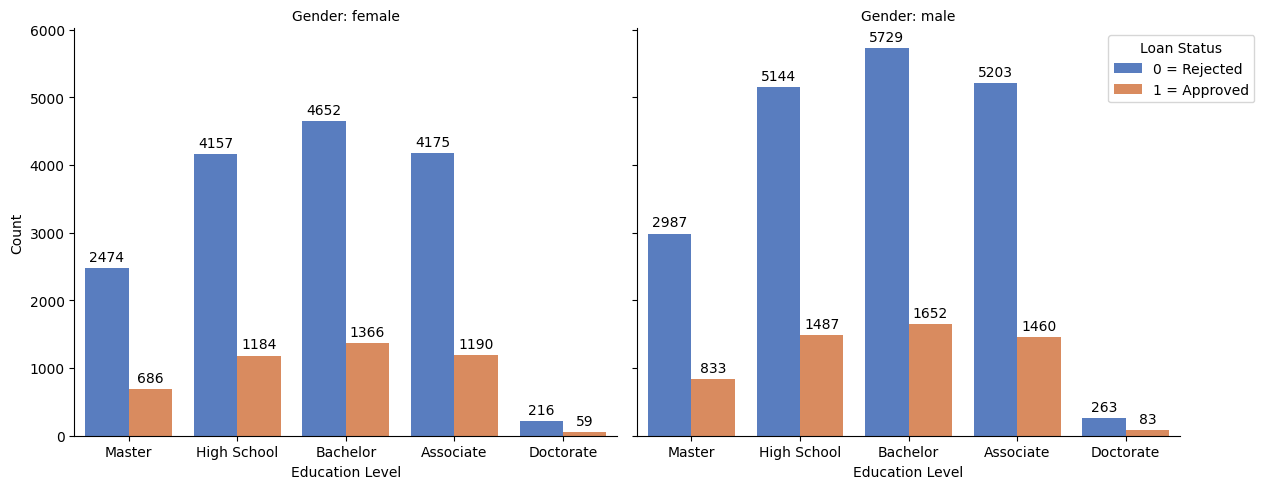

In [ ]:
# Create the catplot for person_education vs loan_status by person_gender
g = sns.catplot(
    data=data,
    x='person_education',
    hue='loan_status',
    col='person_gender',
    kind='count',
    height=5,
    aspect=1.2,
    palette='muted',
    legend=False
)

# Set axis labels and titles
g.set_axis_labels("Education Level", "Count")
g.set_titles("Gender: {col_name}")

# Annotate bars with counts
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center',
                    va='baseline',
                    fontsize=10,
                    color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

# Add legend for loan status
plt.legend(
    title="Loan Status",
    loc='upper right',
    labels=['0 = Rejected', '1 = Approved'],
    bbox_to_anchor=(1.15, 1)
)

# Show the plot
plt.show()

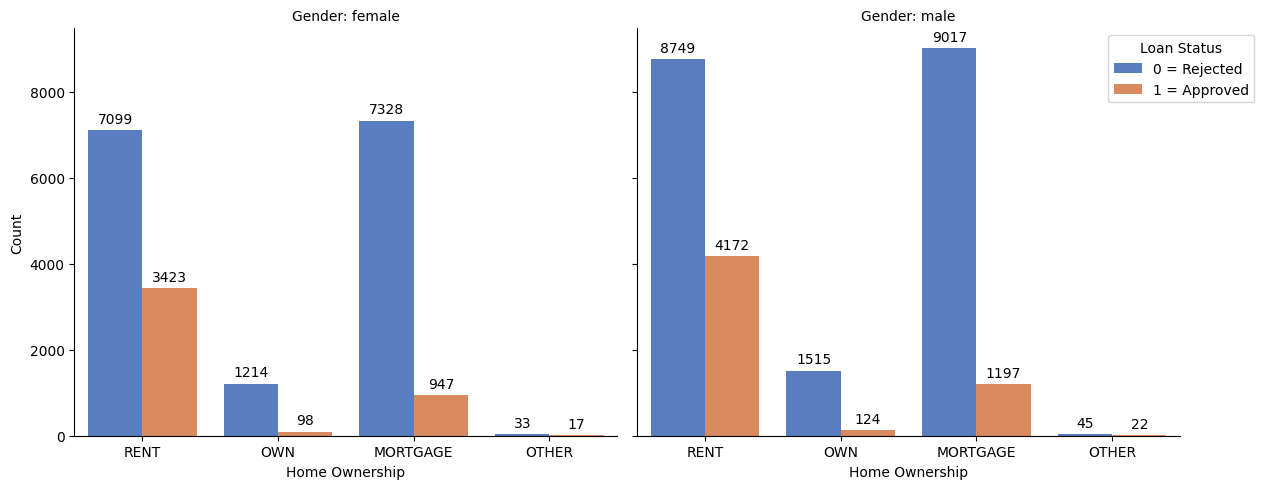

In [ ]:
# Create the catplot for person_home_ownership vs loan_status by person_gender
g = sns.catplot(
    data=data,
    x='person_home_ownership',
    hue='loan_status',
    col='person_gender',
    kind='count',
    height=5,
    aspect=1.2,
    palette='muted',
    legend=False
)

# Set axis labels and titles
g.set_axis_labels("Home Ownership", "Count")
g.set_titles("Gender: {col_name}")

# Annotate bars with counts
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center',
                    va='baseline',
                    fontsize=10,
                    color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

# Add legend for loan status
plt.legend(
    title="Loan Status",
    loc='upper right',
    labels=['0 = Rejected', '1 = Approved'],
    bbox_to_anchor=(1.15, 1)
)

# Show the plot
plt.show()

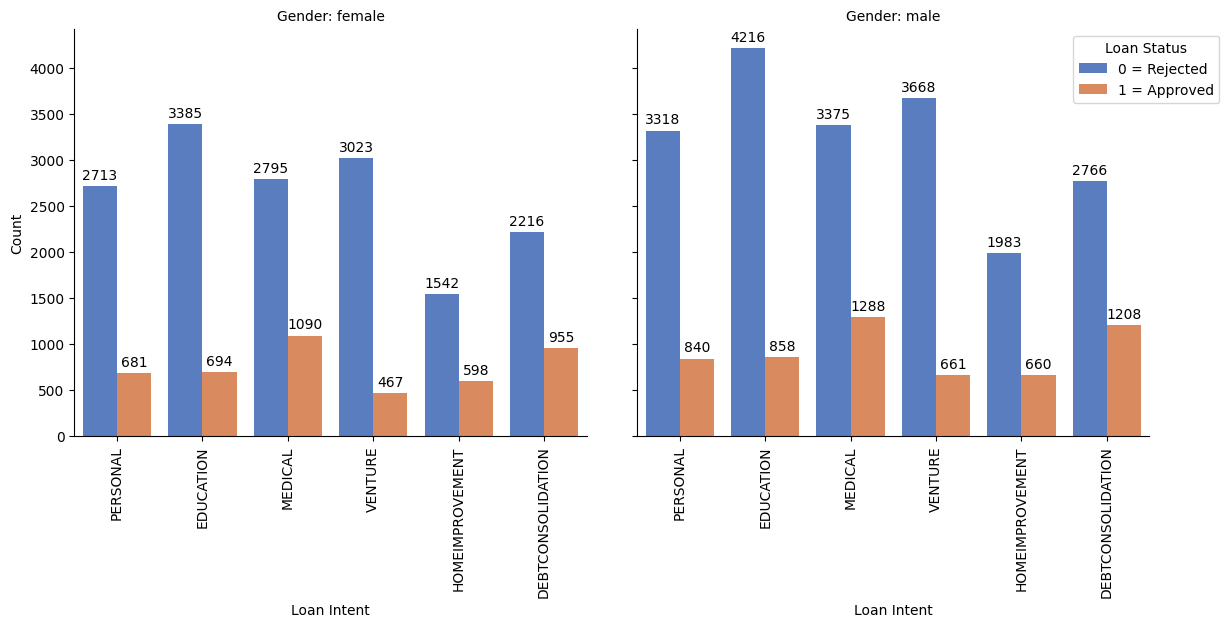

In [ ]:
# Create the catplot for loan_intent vs loan_status by person_gender
g = sns.catplot(
    data=data,
    x='loan_intent',
    hue='loan_status',
    col='person_gender',
    kind='count',
    height=5,
    aspect=1.2,
    palette='muted',
    legend=False
)

# Set axis labels and titles
g.set_axis_labels("Loan Intent", "Count")
g.set_titles("Gender: {col_name}")

# Rotate x-axis labels by 90 degrees
for ax in g.axes.flat:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

# Annotate bars with counts
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center',
                    va='baseline',
                    fontsize=10,
                    color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

# Add legend for loan status
plt.legend(
    title="Loan Status",
    loc='upper right',
    labels=['0 = Rejected', '1 = Approved'],
    bbox_to_anchor=(1.15, 1)
)

# Show the plot
plt.show()

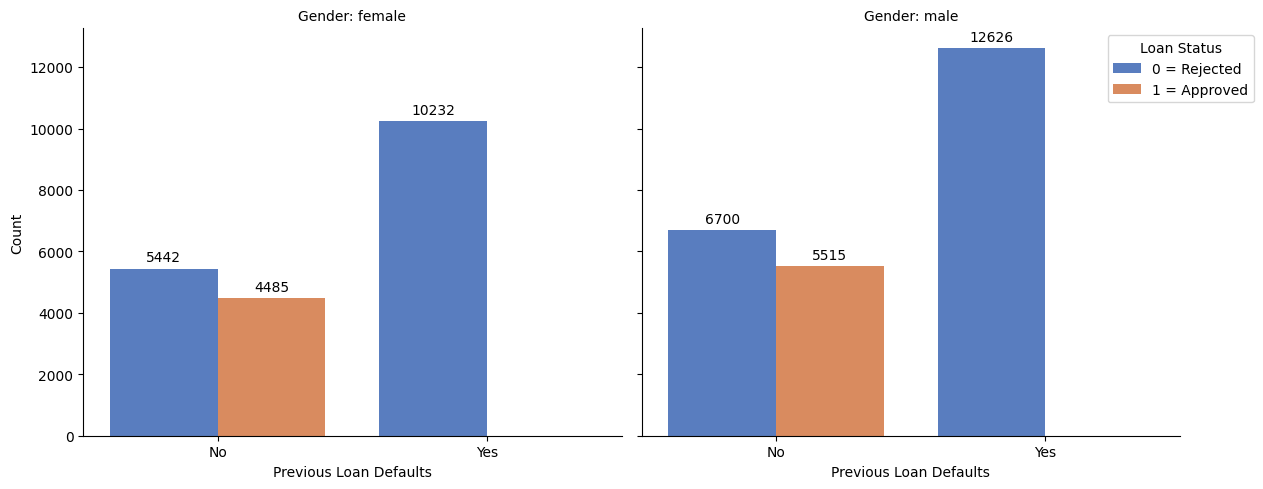

In [ ]:
# Create the catplot for previous_loan_defaults_on_file vs loan_status by person_gender
g = sns.catplot(
    data=data,
    x='previous_loan_defaults_on_file',
    hue='loan_status',
    col='person_gender',
    kind='count',
    height=5,
    aspect=1.2,
    palette='muted',
    legend=False
)

# Set axis labels and titles
g.set_axis_labels("Previous Loan Defaults", "Count")
g.set_titles("Gender: {col_name}")

# Annotate bars with counts
for ax in g.axes.flat:
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center',
                    va='baseline',
                    fontsize=10,
                    color='black',
                    xytext=(0, 5),
                    textcoords='offset points')

# Add legend for loan status
plt.legend(
    title="Loan Status",
    loc='upper right',
    labels=['0 = Rejected', '1 = Approved'],
    bbox_to_anchor=(1.15, 1)
)

# Show the plot
plt.show()

# **Data preprocessing**

In [ ]:
# Binary Encoding for person_gender
data['person_gender'] = data['person_gender'].map({'female': 0, 'male': 1})
# Binary Encoding for previous_loan_defaults_on_file
data['previous_loan_defaults_on_file'] = data['previous_loan_defaults_on_file'].map({'No': 0, 'Yes': 1})

# Ordinal Encoding for person_education (if applicable)
education_order = {'High School': 1, 'Associate': 2, 'Bachelor': 3,
                   'Master': 4, 'Doctorate': 5}
data['person_education'] = data['person_education'].map(education_order)

# One-Hot Encoding for person_home_ownership and loan_intent
data = pd.get_dummies(data, columns=['person_home_ownership', 'loan_intent'], drop_first=True)

In [ ]:
# Display the transformed DataFrame
data.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,4,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,False,False,True,False,False,False,True,False
1,21.0,0,1,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,False,True,False,True,False,False,False,False
2,25.0,0,1,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,False,False,False,False,False,True,False,False
3,23.0,0,3,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,False,False,True,False,False,True,False,False
4,24.0,1,4,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,False,False,True,False,False,True,False,False


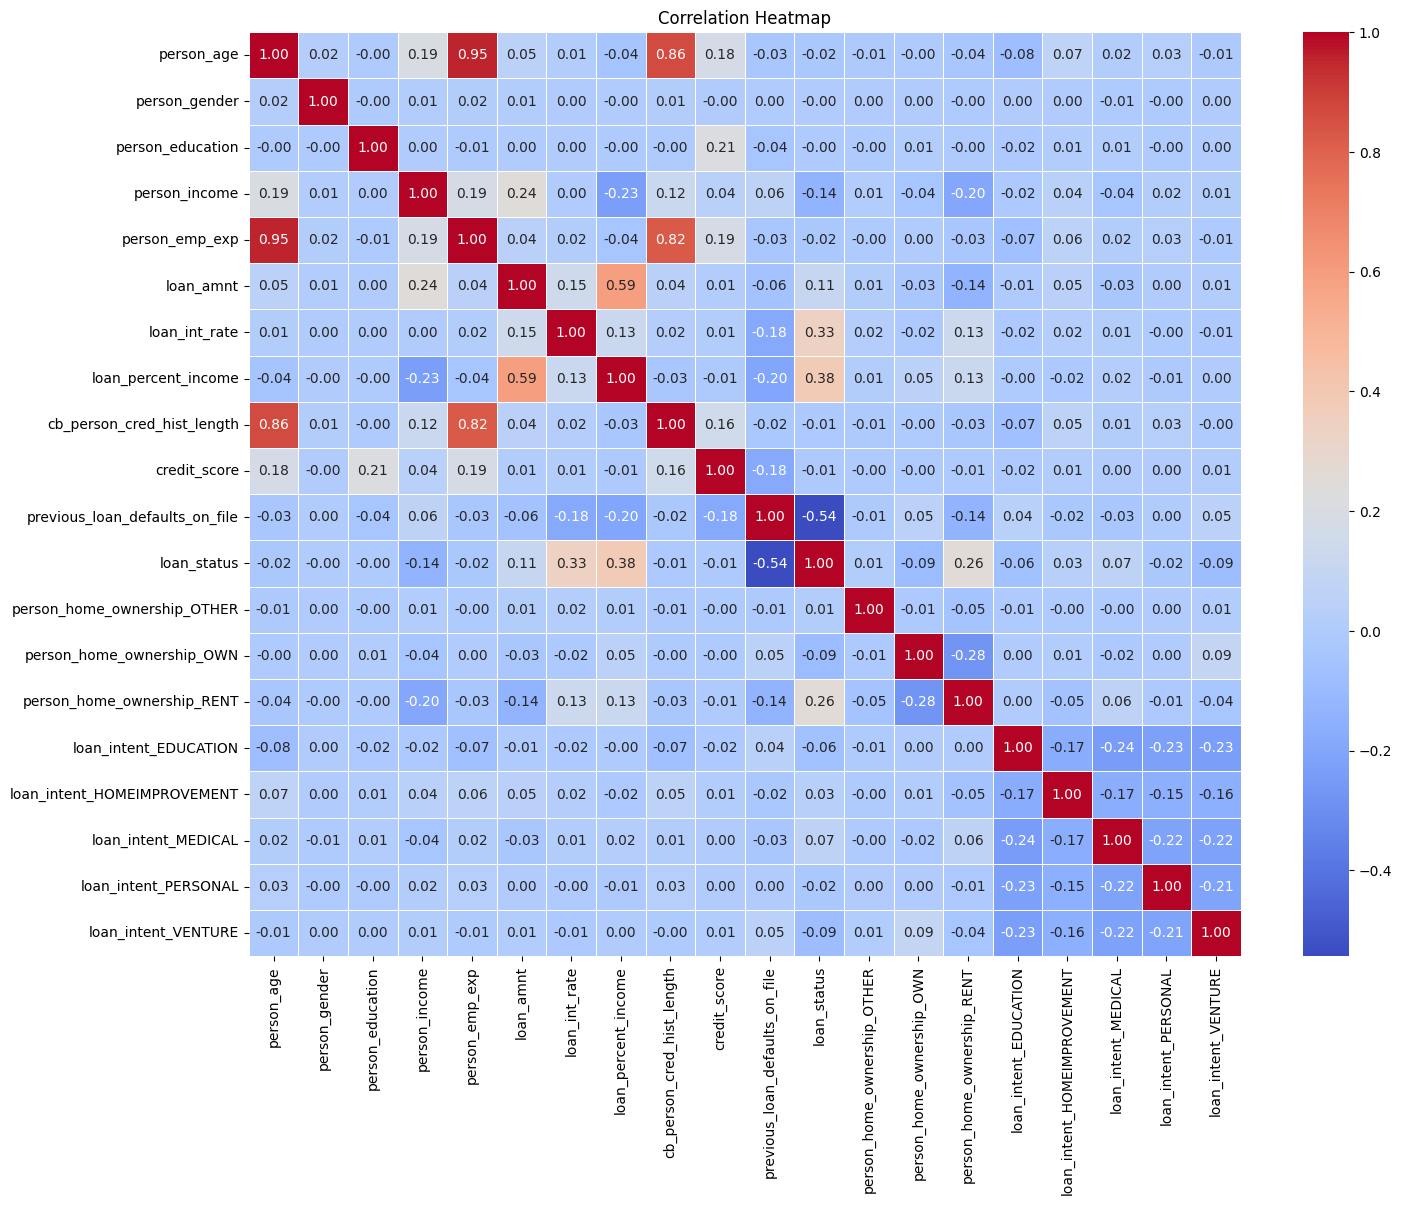

In [ ]:
corr_matrix = data.corr()

# Plotting the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

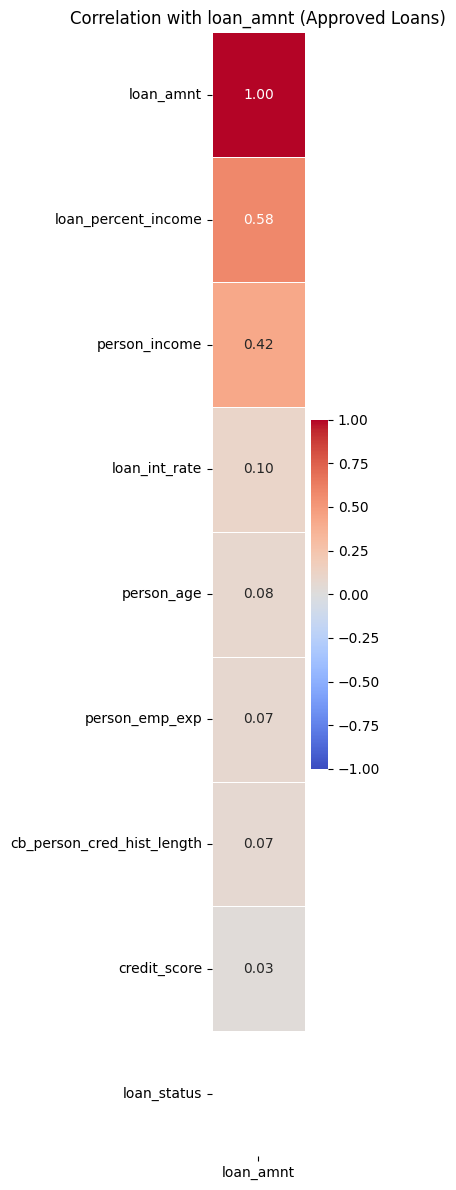

In [ ]:
# Heatmap for approved Loan Ammount
# Filter for approved loans
approved_data = data[data['loan_status'] == 1]

# Ensure loan_amnt is in numerical_columns
if 'loan_amnt' not in numerical_columns:
    raise ValueError("loan_amnt not found in numerical columns")

# Compute correlation matrix
corr_matrix = approved_data[numerical_columns].corr(method='pearson')

# Narrow Heatmap: Correlations with loan_amnt
target_variable = 'loan_amnt'
target_corr = corr_matrix[[target_variable]].sort_values(by=target_variable, ascending=False)

plt.figure(figsize=(4, 12))  # Increased height for more columns
sns.heatmap(target_corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title(f'Correlation with {target_variable} (Approved Loans)', fontsize=12)
plt.tight_layout()
plt.show()

# **Model Tranning and Validation**

In [ ]:
# Copy data to avoid modifying original
data_processed = data.copy()
data_processed.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,4,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,False,False,True,False,False,False,True,False
1,21.0,0,1,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,False,True,False,True,False,False,False,False
2,25.0,0,1,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,False,False,False,False,False,True,False,False
3,23.0,0,3,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,False,False,True,False,False,True,False,False
4,24.0,1,4,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,False,False,True,False,False,True,False,False


In [ ]:
# Handle outliers
numerical_columns = ['person_age', 'person_income', 'person_emp_exp', 'loan_int_rate', 'loan_percent_income',
                     'cb_person_cred_hist_length', 'credit_score']
for col in numerical_columns:
    if col in data_processed.columns:
        Q1 = data_processed[col].quantile(0.25)
        Q3 = data_processed[col].quantile(0.75)
        IQR = Q3 - Q1
        data_processed[col] = data_processed[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)

In [ ]:
# Feature engineering
data_processed['income_int_rate'] = data_processed['person_income'] * data_processed['loan_int_rate']
data_processed['edu_income'] = data_processed['person_education'] * data_processed['person_income']

In [ ]:
# Preprocess not-approved loans' loan_amnt using KNN
approved_data = data_processed[data_processed['loan_status'] == 1].copy()
not_approved_data = data_processed[data_processed['loan_status'] == 0].copy()
if not not_approved_data.empty:
    knn_features = ['person_income', 'credit_score', 'loan_int_rate', 'person_education',
                    'person_home_ownership_RENT', 'loan_intent_VENTURE']
    knn = KNeighborsRegressor(n_neighbors=5)
    knn.fit(approved_data[knn_features], approved_data['loan_amnt'])
    estimated_amnts = knn.predict(not_approved_data[knn_features])
    not_approved_data['loan_amnt'] = estimated_amnts
    data_processed = pd.concat([approved_data, not_approved_data], axis=0)

In [ ]:
# Correlation-based feature selection (numerical features)
approved_data = data_processed[data_processed['loan_status'] == 1]
corr_matrix = approved_data.select_dtypes(include=['int64', 'float64']).corr()
target_variable = 'loan_amnt'
corr_threshold = 0.2
strong_features = corr_matrix[target_variable][abs(corr_matrix[target_variable]) > corr_threshold].index.tolist()
if target_variable in strong_features:
    strong_features.remove(target_variable)
if 'loan_status' in strong_features:
    strong_features.remove('loan_status')

# Multicollinearity check
for col1 in strong_features[:]:
    for col2 in strong_features[:]:
        if col1 < col2 and col1 in corr_matrix and col2 in corr_matrix:
            if abs(corr_matrix.loc[col1, col2]) > 0.95:
                if abs(corr_matrix.loc[col1, target_variable]) > abs(corr_matrix.loc[col2, target_variable]):
                    if col2 in strong_features:
                        strong_features.remove(col2)
                else:
                    if col1 in strong_features:
                        strong_features.remove(col1)

print(f"Selected features: {strong_features}")
print(f"Number of features for training: {len(strong_features)}")

Selected features: ['person_income', 'loan_percent_income', 'income_int_rate', 'edu_income']
Number of features for training: 4


In [ ]:
# Add categorical features via feature importance
X_temp = data_processed.drop(['loan_amnt'], axis=1)
y_temp = data_processed['loan_amnt']
X_train_temp, _, y_train_temp, _ = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
scaler_temp = RobustScaler()
X_train_temp = scaler_temp.fit_transform(X_train_temp)
model_temp = RandomForestRegressor(max_depth=15, random_state=42)
model_temp.fit(X_train_temp, y_train_temp)
importance_df = pd.DataFrame({'Feature': X_temp.columns, 'Importance': model_temp.feature_importances_})
strong_features += importance_df[importance_df['Importance'] > 0.03]['Feature'].tolist()  # Lower threshold
strong_features = list(set(strong_features))

# Ensure key categorical features
key_categorical = ['person_education', 'person_home_ownership_RENT', 'loan_intent_VENTURE']
strong_features.extend([f for f in key_categorical if f in data_processed.columns])
strong_features = list(set(strong_features))

print(f"Selected features: {strong_features}")
print(f"Number of features for training: {len(strong_features)}")
print(f"Correlation with loan_amnt:\n{corr_matrix[target_variable][[f for f in strong_features if f in corr_matrix.index]].sort_values(ascending=False)}")

Selected features: ['person_home_ownership_RENT', 'income_int_rate', 'edu_income', 'loan_intent_VENTURE', 'person_income', 'person_education', 'loan_status', 'loan_percent_income']
Number of features for training: 8
Correlation with loan_amnt:
loan_percent_income    0.589037
person_income          0.506032
income_int_rate        0.464592
edu_income             0.367123
person_education       0.000777
loan_status                 NaN
Name: loan_amnt, dtype: float64


In [ ]:
# Separate features and target
X = data_processed[strong_features]
y = data_processed['loan_amnt']

In [ ]:
# Stratified split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42,
                                                  stratify=data_processed['loan_status'])

In [ ]:
# Apply RobustScaler
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [ ]:
# Models
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(max_depth=12, min_samples_split=5, min_samples_leaf=5,
                                          max_features='log2', random_state=42)
}

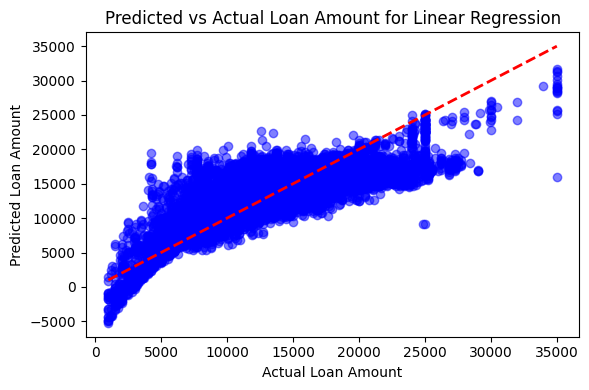

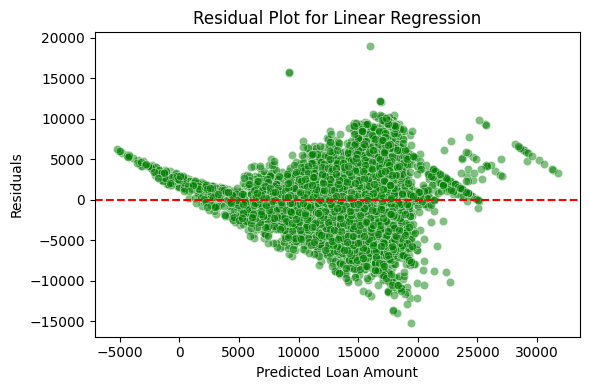

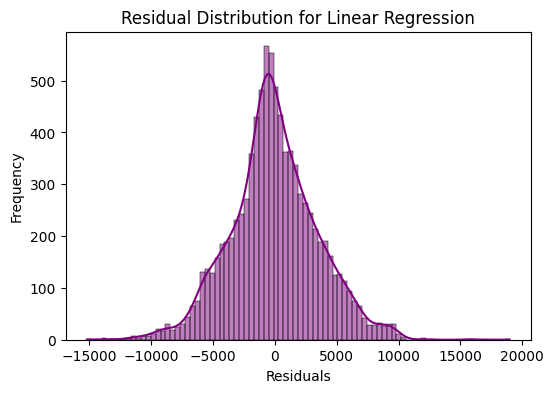

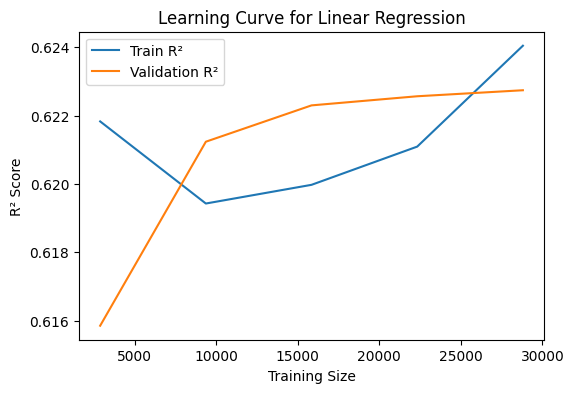

Metrics for Linear Regression:
Mean Squared Error: 12498268.13
Root Mean Squared Error: 3535.29
Mean Absolute Error: 2708.38
Median Absolute Error: 2075.58
R² Score: 0.62
Cross-Validation R²: 0.62




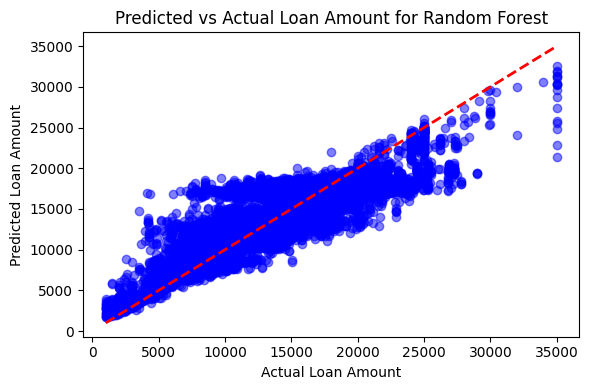

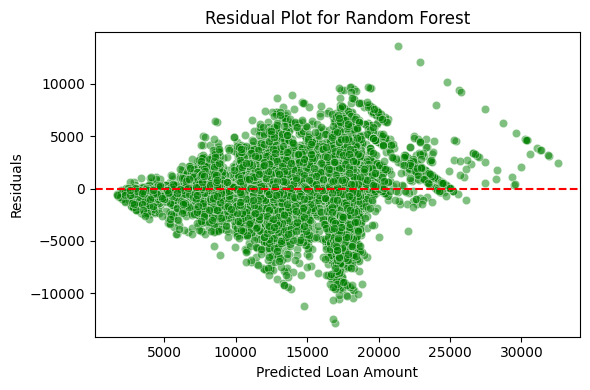

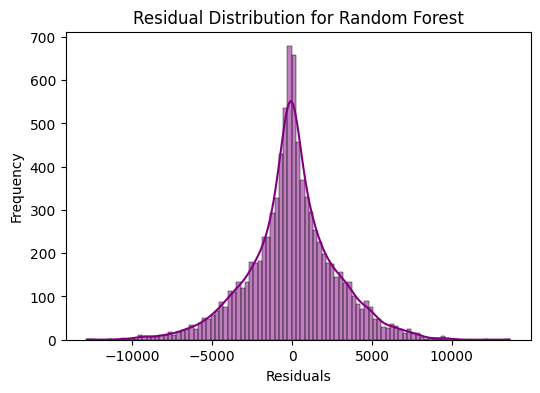

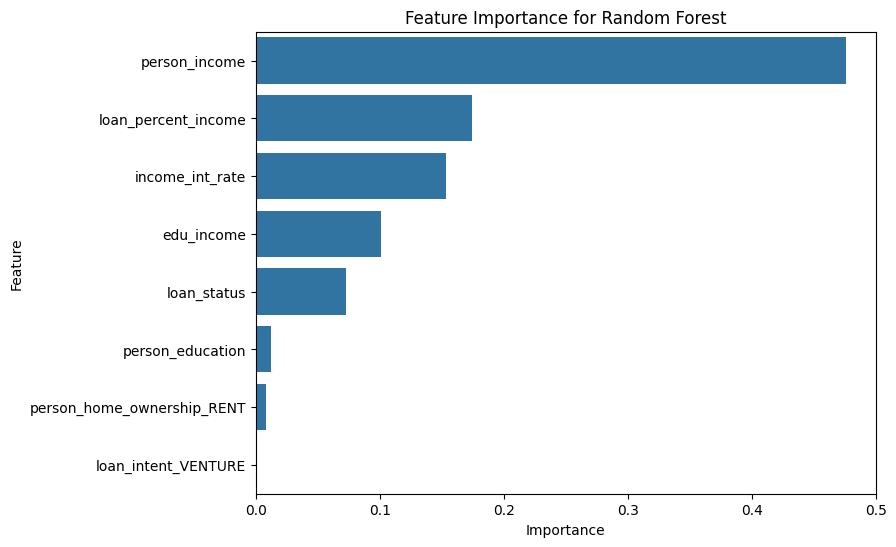

Feature Importance for Random Forest:
                      Feature  Importance
4               person_income    0.476309
7         loan_percent_income    0.174544
1             income_int_rate    0.153064
2                  edu_income    0.101210
6                 loan_status    0.072627
5            person_education    0.012651
0  person_home_ownership_RENT    0.008512
3         loan_intent_VENTURE    0.001083


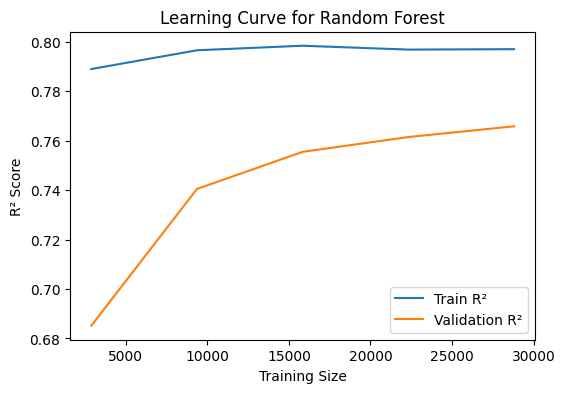

Metrics for Random Forest:
Mean Squared Error: 7590916.18
Root Mean Squared Error: 2755.16
Mean Absolute Error: 1997.61
Median Absolute Error: 1395.97
R² Score: 0.77
Cross-Validation R²: 0.77


Model Performance Table:


,Model,Train R² Score,Test R² Score,Mean Squared Error,Root Mean Squared Error,Mean Absolute Error,Median Absolute Error,R² Score,Cross-Validation R²
0,Linear Regression,0.623916,0.622944,1.249827e+07,3535.288975,2708.376438,2075.580833,0.622944,0.622740
1,Random Forest,0.798995,0.770992,7.590916e+06,2755.161734,1997.605306,1395.969473,0.770992,0.765759


Baseline (Mean Prediction) - MSE: 33147846.34, MAE: 4677.43, R²: -0.00


['robust_scaler.pkl']

In [ ]:
# Results
results = []

for name, model in models.items():
    # Apply polynomial features for Linear Regression
    if name == "Linear Regression":
        poly = PolynomialFeatures(degree=2, include_bias=False)
        X_train_mod = poly.fit_transform(X_train)
        X_val_mod = poly.transform(X_val)
    else:
        X_train_mod = X_train
        X_val_mod = X_val

    model.fit(X_train_mod, y_train)
    y_val_pred = model.predict(X_val_mod)

    train_score = model.score(X_train_mod, y_train)
    test_score = model.score(X_val_mod, y_val)

    mse = mean_squared_error(y_val, y_val_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_val, y_val_pred)
    medae = median_absolute_error(y_val, y_val_pred)
    r2 = r2_score(y_val, y_val_pred)

    cv_r2 = cross_val_score(model, X_train_mod, y_train, cv=5, scoring='r2').mean()

    results.append({
        'Model': name,
        'Train R² Score': train_score,
        'Test R² Score': test_score,
        'Mean Squared Error': mse,
        'Root Mean Squared Error': rmse,
        'Mean Absolute Error': mae,
        'Median Absolute Error': medae,
        'R² Score': r2,
        'Cross-Validation R²': cv_r2
    })

    plt.figure(figsize=(6, 4))
    plt.scatter(y_val, y_val_pred, alpha=0.5, color='blue')
    plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
    plt.title(f'Predicted vs Actual Loan Amount for {name}')
    plt.xlabel('Actual Loan Amount')
    plt.ylabel('Predicted Loan Amount')
    plt.tight_layout()
    plt.show()

    residuals = y_val - y_val_pred
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=y_val_pred, y=residuals, alpha=0.5, color='green')
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f'Residual Plot for {name}')
    plt.xlabel('Predicted Loan Amount')
    plt.ylabel('Residuals')
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    sns.histplot(residuals, kde=True, color='purple')
    plt.title(f'Residual Distribution for {name}')
    plt.xlabel('Residuals')
    plt.ylabel('Frequency')
    plt.show()

    if name == "Random Forest":
        importance_df = pd.DataFrame({'Feature': strong_features, 'Importance': model.feature_importances_})
        plt.figure(figsize=(8, 6))
        sns.barplot(x='Importance', y='Feature', data=importance_df.sort_values('Importance', ascending=False))
        plt.title(f'Feature Importance for {name}')
        plt.show()
        print(f"Feature Importance for {name}:\n{importance_df.sort_values('Importance', ascending=False)}")

    # Learning curve
    train_sizes, train_scores, val_scores = learning_curve(model, X_train_mod, y_train, cv=5, scoring='r2')
    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_scores.mean(axis=1), label='Train R²')
    plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation R²')
    plt.title(f'Learning Curve for {name}')
    plt.xlabel('Training Size')
    plt.ylabel('R² Score')
    plt.legend()
    plt.show()

    print(f"Metrics for {name}:")
    print(f"Mean Squared Error: {mse:.2f}")
    print(f"Root Mean Squared Error: {rmse:.2f}")
    print(f"Mean Absolute Error: {mae:.2f}")
    print(f"Median Absolute Error: {medae:.2f}")
    print(f"R² Score: {r2:.2f}")
    print(f"Cross-Validation R²: {cv_r2:.2f}")
    print("\n" + "="*60 + "\n")

results_df = pd.DataFrame(results)
print("Model Performance Table:")
display(results_df)

baseline_pred = np.full_like(y_val, y_train.mean())
baseline_mse = mean_squared_error(y_val, baseline_pred)
baseline_mae = mean_absolute_error(y_val, baseline_pred)
baseline_r2 = r2_score(y_val, baseline_pred)
print(f"Baseline (Mean Prediction) - MSE: {baseline_mse:.2f}, MAE: {baseline_mae:.2f}, R²: {baseline_r2:.2f}")

joblib.dump(models["Random Forest"], 'random_forest_model.pkl')
joblib.dump(scaler, 'robust_scaler.pkl')